# EDA: `customers`

Разведочный анализ таблицы `customers` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM customers"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP,14409
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,09790
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,01151
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,08775
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,13056


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_city             99441 non-null  str  
 3   customer_state            99441 non-null  str  
 4   customer_zip_code_prefix  99441 non-null  str  
dtypes: str(5)
memory usage: 3.8 MB


In [8]:
df.describe(include='all')

,customer_id,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix
count,99441,99441,99441,99441,99441
unique,99441,96096,4119,27,14994
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP,22790
freq,1,17,15540,41746,142


In [9]:
df.memory_usage(deep=True)

Index                           132
customer_id                 8054721
customer_unique_id          8054721
customer_city               5901273
customer_state              5071491
customer_zip_code_prefix    5369814
dtype: int64

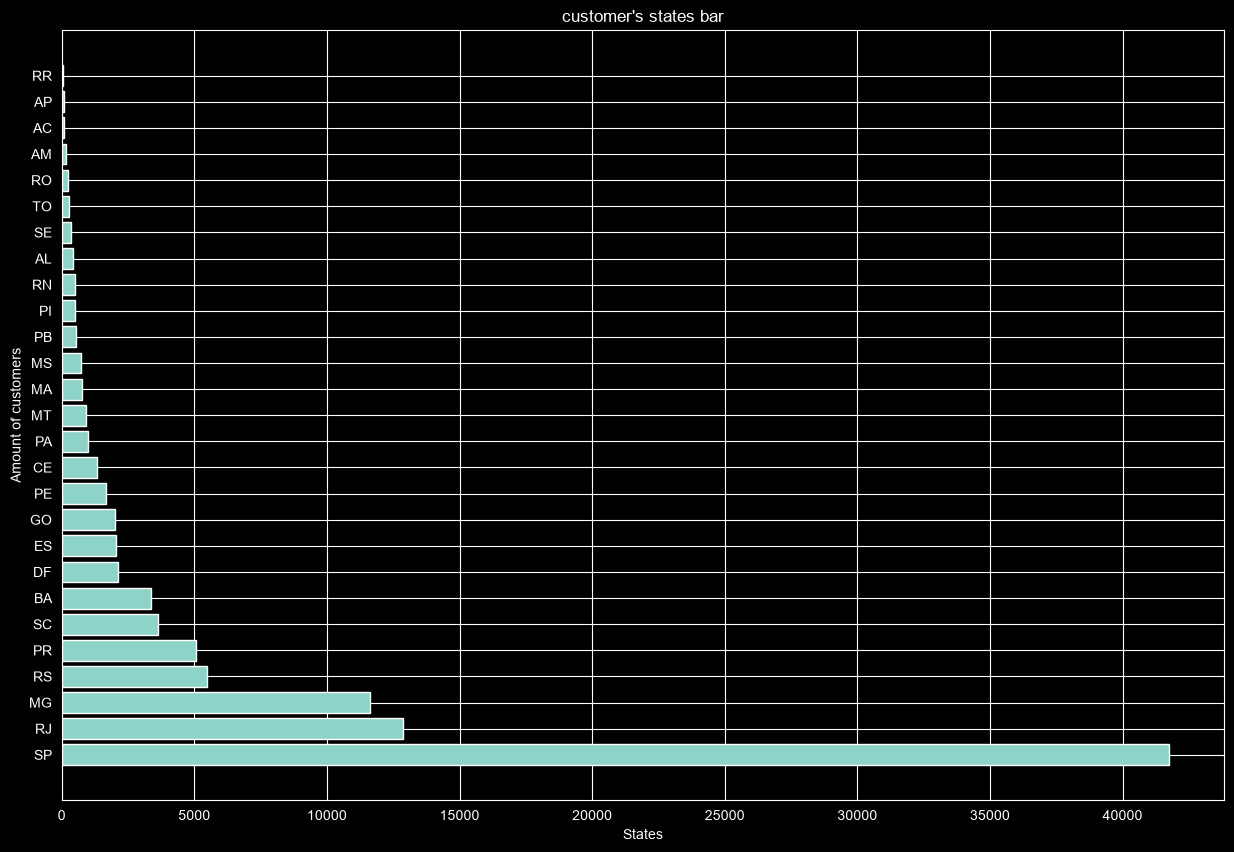

In [10]:
sampling_data = df['customer_state'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(15, 10))
plt.barh(categories, values)

plt.title("customer's states bar")
plt.xlabel('States')
plt.ylabel('Amount of customers')

plt.show()